                                                  FNN with Keras

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load & Preprocess Data 

df = pd.read_csv(r"C:\Users\PIYUSH\Downloads\StarGalaxyQuaser1_TwinkleKashyap.csv")

df.drop('objid', axis=1, inplace=True)

# Feature engineering
df['u-g'] = df['u'] - df['g']
df['g-r'] = df['g'] - df['r']
df['r-i'] = df['r'] - df['i']
df['i-z'] = df['i'] - df['z']

# Data Cleaning
df = df[(df['u-g'] > -5) & (df['u-g'] < 5) &
        (df['g-r'] > -5) & (df['g-r'] < 5)]

# Encode labels
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

# Features & target
X = df.drop('class', axis=1).values
y = df['class'].values

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(le.classes_)

['GALAXY' 'QSO' 'STAR']


In [4]:
import os
import random
import numpy as np
import tensorflow as tf

# Python
random.seed(42)

# NumPy
np.random.seed(42)

# TensorFlow
tf.random.set_seed(42)


os.environ['PYTHONHASHSEED'] = '42'

In [5]:
#  Scaling 

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#  Scaling 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

#  Compile 

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#  Train 

history = model.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

#  Evaluate 

loss, acc = model.evaluate(X_test, Y_test)
print("Test Accuracy:", acc)

#  Predictions 

y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)

from sklearn.metrics import classification_report, confusion_matrix

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_pred))

print("\nClassification Report:")
print(classification_report(Y_test, y_pred))

C:\Users\PIYUSH\anaconda3\envs\astro_physics\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9497 - loss: 0.1800 - val_accuracy: 0.9794 - val_loss: 0.0877
Epoch 2/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9839 - loss: 0.0671 - val_accuracy: 0.9851 - val_loss: 0.0622
Epoch 3/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9868 - loss: 0.0534 - val_accuracy: 0.9849 - val_loss: 0.0564
Epoch 4/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9881 - loss: 0.0473 - val_accuracy: 0.9858 - val_loss: 0.0524
Epoch 5/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9888 - loss: 0.0440 - val_accuracy: 0.9858 - val_loss: 0.0515
Epoch 6/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9895 - loss: 0.0410 - val_accuracy: 0.9875 - val_loss: 0.0470
Epoch 7/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9898 - loss: 0.0402 - val_accuracy: 0.9864 - val_loss: 0.0499
Epoch 8/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9901 - loss: 0.0393 - val_accuracy: 0.

                                               Class weighting

In [7]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(Y_train)
weights = compute_class_weight('balanced', classes=classes, y=Y_train)

class_weights = dict(zip(classes, weights))

In [8]:
# Model 

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

#  Compile 

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train 

history = model.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights
)

#  Evaluate 

loss, acc = model.evaluate(X_test, Y_test)
print("Test Accuracy:", acc)

# Predictions

y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)

from sklearn.metrics import classification_report, confusion_matrix

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_pred))

print("\nClassification Report:")
print(classification_report(Y_test, y_pred))

C:\Users\PIYUSH\anaconda3\envs\astro_physics\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9312 - loss: 0.2004 - val_accuracy: 0.9757 - val_loss: 0.1015
Epoch 2/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9772 - loss: 0.0901 - val_accuracy: 0.9817 - val_loss: 0.0750
Epoch 3/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9818 - loss: 0.0760 - val_accuracy: 0.9840 - val_loss: 0.0655
Epoch 4/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9834 - loss: 0.0705 - val_accuracy: 0.9858 - val_loss: 0.0606
Epoch 5/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9844 - loss: 0.0669 - val_accuracy: 0.9850 - val_loss: 0.0610
Epoch 6/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9851 - loss: 0.0645 - val_accuracy: 0.9853 - val_loss: 0.0583
Epoch 7/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9858 - loss: 0.0623 - val_accuracy: 0.9864 - val_loss: 0.0553
Epoch 8/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9861 - loss: 0.0610 - val_accuracy: 0.

In [9]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',linewidths=0.5, linecolor='black')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

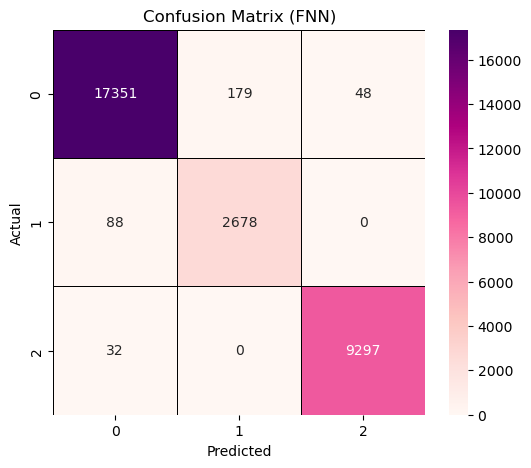

In [10]:
plot_conf_matrix(Y_test, y_pred, "Confusion Matrix (FNN)")

In [7]:
import shap

explainer = shap.Explainer(model.predict, X_train[:100])

C:\Users\PIYUSH\anaconda3\envs\astro_physics\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
shap_values = explainer(X_test[:1000])

3200/3200 ━━━━━━━━━━━━━━━━━━━━ 3s 993us/step


ExactExplainer explainer:   0%|                                                               | 1/1000 [00:00<?, ?it/s]

3200/3200 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:   0%|▏                                                      | 3/1000 [00:26<40:08,  2.42s/it]

3199/3199 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


...

ExactExplainer explainer: 100%|██████████████████████████████████████████████████▉| 999/1000 [1:28:03<00:03,  3.68s/it]

3200/3200 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


ExactExplainer explainer: 100%|██████████████████████████████████████████████████| 1000/1000 [1:28:06<00:00,  3.67s/it]

3196/3196 ━━━━━━━━━━━━━━━━━━━━ 3s 829us/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


ExactExplainer explainer: 1001it [1:28:10,  5.29s/it]                                                                  


In [13]:
feature_names = df.drop('class', axis=1).columns.tolist()
shap_values.feature_names = feature_names

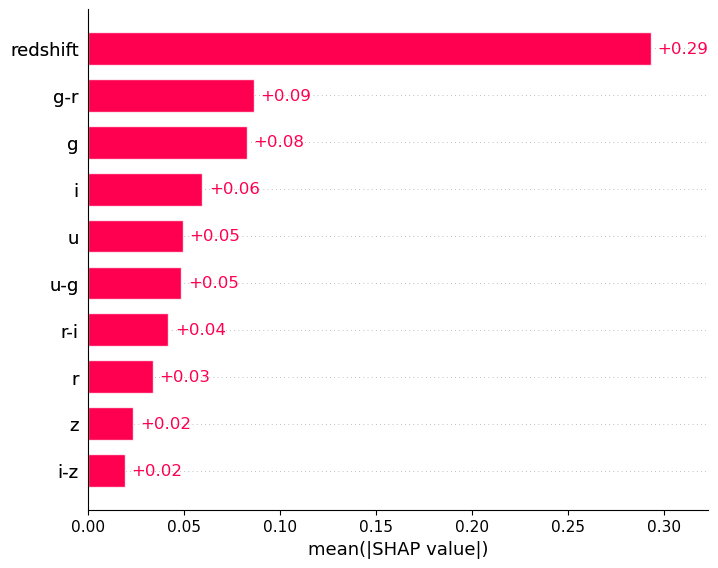

In [16]:
class_idx = 0
shap.plots.bar(shap_values[:, :, class_idx])

                                                   Without Redshift 

In [11]:
#  REMOVE REDSHIFT 

X_train_no_z = np.delete(X_train, 5, axis=1)
X_test_no_z = np.delete(X_test, 5, axis=1)

In [12]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(Y_train)
weights = compute_class_weight('balanced', classes=classes, y=Y_train)

class_weights = dict(zip(classes, weights))

In [13]:
#  Model

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_no_z.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

#  Compile 
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#  Train 

history = model.fit(
    X_train_no_z, Y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights
)

#  Evaluate 

loss, acc = model.evaluate(X_test_no_z, Y_test)
print("Test Accuracy:", acc)

#  Predictions 
y_pred = model.predict(X_test_no_z)
y_pred = y_pred.argmax(axis=1)

from sklearn.metrics import classification_report, confusion_matrix

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_pred))

print("\nClassification Report:")
print(classification_report(Y_test, y_pred))

Epoch 1/50


C:\Users\PIYUSH\anaconda3\envs\astro_physics\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


866/866 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8489 - loss: 0.4549 - val_accuracy: 0.8944 - val_loss: 0.3432
Epoch 2/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8939 - loss: 0.3484 - val_accuracy: 0.9050 - val_loss: 0.3053
Epoch 3/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9003 - loss: 0.3229 - val_accuracy: 0.9099 - val_loss: 0.2838
Epoch 4/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9043 - loss: 0.3073 - val_accuracy: 0.9129 - val_loss: 0.2703
Epoch 5/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9077 - loss: 0.2971 - val_accuracy: 0.9148 - val_loss: 0.2636
Epoch 6/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9097 - loss: 0.2897 - val_accuracy: 0.9162 - val_loss: 0.2599
Epoch 7/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9117 - loss: 0.2840 - val_accuracy: 0.9170 - val_loss: 0.2579
Epoch 8/50
866/866 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9122 - loss: 0.2792 - val_accuracy: 0.9178 - val_

In [14]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd',linewidths=0.5, linecolor='black')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

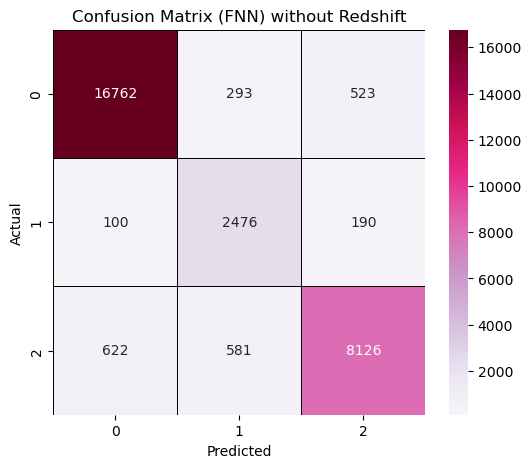

In [15]:
plot_conf_matrix(Y_test, y_pred, "Confusion Matrix (FNN) without Redshift")

In [20]:
explainer = shap.Explainer(model.predict, X_train_no_z[:100])

In [21]:
shap_values = explainer(X_test_no_z[:1000])

1600/1600 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/step
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 1s 778us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 1s 804us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 1s 850us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 1s 925us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


ExactExplainer explainer:   1%|▍                                                              | 6/1000 [00:00<?, ?it/s]

1600/1600 ━━━━━━━━━━━━━━━━━━━━ 1s 885us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


ExactExplainer explainer:   1%|▍                                                      | 8/1000 [00:13<16:20,  1.01it/s]

1600/1600 ━━━━━━━━━━━━━━━━━━━━ 1s 849us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


...

ExactExplainer explainer: 100%|████████████████████████████████████████████████████▉| 999/1000 [32:22<00:01,  1.99s/it]

1600/1600 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


ExactExplainer explainer: 100%|████████████████████████████████████████████████████| 1000/1000 [32:24<00:00,  1.96s/it]

1598/1598 ━━━━━━━━━━━━━━━━━━━━ 1s 854us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


ExactExplainer explainer: 1001it [32:26,  1.96s/it]                                                                    


In [24]:
feature_names = df.drop('class', axis=1).columns.tolist()
shap_values.feature_names = feature_names

feature_names.remove('redshift')

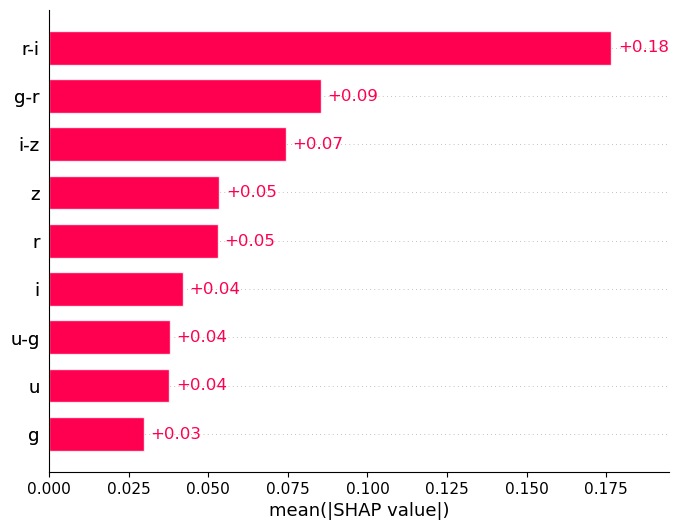

In [25]:
class_idx = 0
shap.plots.bar(shap_values[:, :, class_idx])

In [26]:
import numpy as np

shap_mean = np.mean(np.abs(shap_values.values), axis=(0, 2))

for name, val in sorted(zip(feature_names, shap_mean), key=lambda x: -x[1]):
    print(f"{name}: {val:.4f}")

r-i: 0.1318
i-z: 0.0661
g-r: 0.0657
i: 0.0567
u-g: 0.0519
z: 0.0477
r: 0.0391
u: 0.0365
g: 0.0339


In [27]:
for i in range(3):
    class_mean = np.mean(np.abs(shap_values.values[:, :, i]), axis=0)
    print(f"\nClass {i}")
    for name, val in sorted(zip(feature_names, class_mean), key=lambda x: -x[1]):
        print(f"{name}: {val:.4f}")


Class 0
r-i: 0.1766
g-r: 0.0853
i-z: 0.0743
z: 0.0534
r: 0.0530
i: 0.0421
u-g: 0.0379
u: 0.0378
g: 0.0297

Class 1
r-i: 0.1019
u-g: 0.0586
i: 0.0506
u: 0.0442
z: 0.0419
g-r: 0.0358
g: 0.0306
i-z: 0.0296
r: 0.0235

Class 2
r-i: 0.1170
i-z: 0.0942
i: 0.0775
g-r: 0.0761
u-g: 0.0594
z: 0.0476
g: 0.0412
r: 0.0409
u: 0.0276


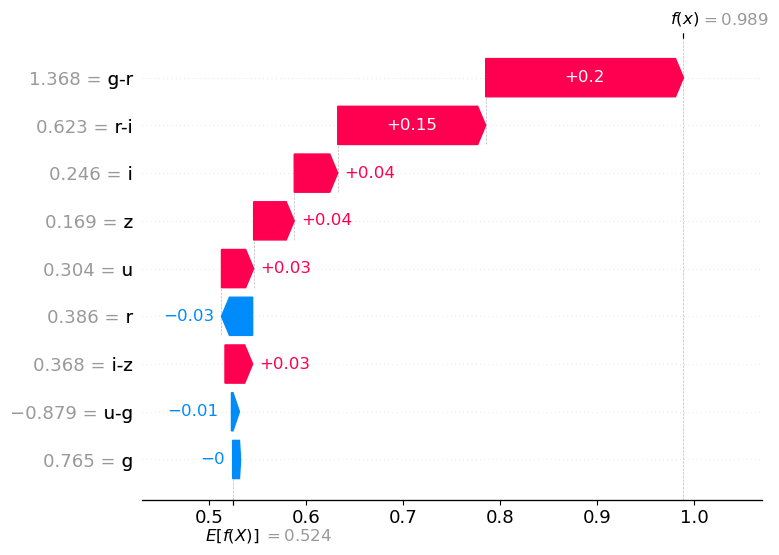

In [28]:
shap.plots.waterfall(shap_values[0, :, class_idx])